In [1]:
from resources.imports import *

from resources.MLdata import *
from resources.MLfunc import *
from resources.MLmodels import MODEL, Autoencoder

In [2]:
DAT = DATA(path=1, 
           path_add="",
           load=True, 
           LAT="FCC", 
           dis="disNodes", 
           mechMode="UT",
           dN=0.2, 
           model="MLP")

# Principal Component Analysis (PCA)

In [3]:
X_data = np.concatenate((DAT.train_in, DAT.val_in, DAT.test_in))
X_data = X_data.reshape(X_data.shape[0], X_data.shape[1]//2, 2)
X_data = (X_data[:,:,0], X_data[:,:,1]) 

Y_data = np.concatenate((DAT.train_out, DAT.val_out, DAT.test_out))

X_data[0].shape, X_data[1].shape, Y_data.shape

((986, 450), (986, 450), (986, 201))

Number of components to capture 50% variance: 1
Number of components to capture 80% variance: 4
Number of components to capture 90% variance: 7
Number of components to capture 95% variance: 10
Number of components to capture 100% variance: 115


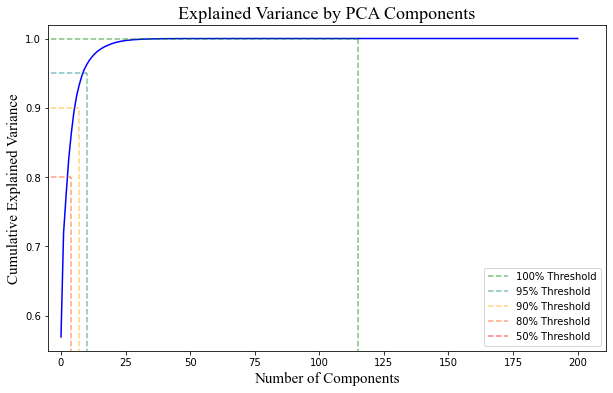

In [4]:
pca = PCA_(scaler=None)
pca.fit(data=Y_data, scale=True, verbose=True, plot=True)

In [5]:
Y_reduced = pca.reduce(data=Y_data, scale=True, accuracy=0.95, n_components=None, verbose=True)
# pd.DataFrame(pca.final_pca.get_covariance())

Original data shape: (986, 201)
Reduced data shape: (986, 10)


In [6]:
Y_recon = pca.reconstruct(data=Y_reduced, scale=False)

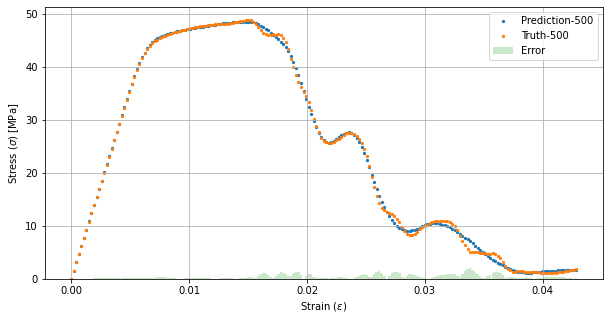

0.8393606496355507

In [7]:
indx = 500
xy = 0

plt_outputs = Y_recon #.reshape(X_recon.shape[1]//2, 2)[:,xy]
truth = Y_data #.reshape(X_recon.shape[1]//2,2)[:,xy]

plot_StressStrainOUT(DAT.perOUT_df.T.to_numpy(), plt_outputs, truth=truth, indx=indx)

np.sqrt(np.mean((plt_outputs - truth) ** 2))

# Autoencoder

In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

in_size = Y_data.shape[-1]
h_size = []
latent_size = 10

BATCH_SIZE = 1
LEARNING_RATE = 1e-3

Using device: cpu


In [32]:
trainDS = Dataset_(Y_data, Y_data)
testDS = Dataset_(Y_data, Y_data)

train_dataloader = DataLoader(dataset=trainDS, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(dataset=testDS, batch_size=BATCH_SIZE, shuffle=False)

In [33]:
ENC = MODEL(
    typ="MLP",
    model=Autoencoder(in_size, latent_size, h_size, block="mlp").to(device), 
    lossf=nn.MSELoss(),
    opt=("adam", 0),
    batch=BATCH_SIZE,
    lr=LEARNING_RATE,
    data=DAT,
    train_dataloader=train_dataloader, 
    val_dataloader=None, 
    test_dataloader=test_dataloader,
    scheduler=("min", 0.7, 10, 1e-4, True), 
    earlyStop=None, #EarlyStopping(patience=50, min_delta=1e-4, verbose=True),
    w_init=weights_init,
)

print(summary(ENC.model, input_size=(BATCH_SIZE, in_size)))

Layer (type:depth-idx)                   Output Shape              Param #
Autoencoder                              [1, 201]                  --
├─MLP: 1-1                               [1, 10]                   --
│    └─Linear: 2-1                       [1, 10]                   2,020
├─MLP: 1-2                               [1, 201]                  --
│    └─Linear: 2-2                       [1, 201]                  2,211
Total params: 4,231
Trainable params: 4,231
Non-trainable params: 0
Total mult-adds (M): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.02
Estimated Total Size (MB): 0.02


c:\Programs\Python39\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch: 1 - Loss: 16.038302453125226 - RMSE Loss: 3.4661749674322877
Epoch: 50 - Loss: 0.8615112885923463 - RMSE Loss: 0.9042372708293106
Epoch: 100 - Loss: 0.7819864478332518 - RMSE Loss: 0.8598766689873864
Epoch: 150 - Loss: 0.7392273579419989 - RMSE Loss: 0.835460227368261
Epoch: 200 - Loss: 0.7275490683123741 - RMSE Loss: 0.828664680710314
Epoch: 250 - Loss: 0.7162522919944527 - RMSE Loss: 0.8217413281150915
Epoch: 300 - Loss: 0.7135103550903937 - RMSE Loss: 0.8202064170268237
Epoch: 350 - Loss: 0.7124309356024009 - RMSE Loss: 0.8195323977656453
Epoch: 400 - Loss: 0.7114418083707411 - RMSE Loss: 0.8189317046406023
Epoch: 450 - Loss: 0.7112223946056792 - RMSE Loss: 0.8187928145270721
Epoch: 500 - Loss: 0.7111596464052887 - RMSE Loss: 0.8187543708669985
Best Epoch: 498, with loss 0.7111586008001777


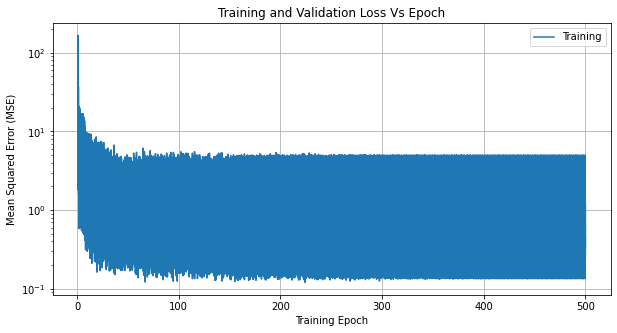

In [34]:
# latents = np.flip(np.linspace(50, in_size-20, (in_size-20)//21, dtype=int))
# min_latent = 0
# for latent in latents:
    # print(f"Starting training attempt with latent size: {latent}")
    
ENC = MODEL(
    typ="MLP",
    model=Autoencoder(in_size, latent_size, h_size, block="mlp").to(device), 
    lossf=nn.MSELoss(),
    opt=("adam", 0),
    batch=BATCH_SIZE,
    lr=LEARNING_RATE,
    data=DAT,
    train_dataloader=train_dataloader, 
    val_dataloader=None, 
    test_dataloader=test_dataloader,
    scheduler=("min", 0.7, 10, 1e-4, True), 
    earlyStop=None, #EarlyStopping(patience=50, min_delta=1e-4, verbose=True),
    w_init=weights_init,
)

# print(summary(ENC.model, input_size=(BATCH_SIZE, in_size)))

ENC.train(n_epochs=500, verbose=50, plot=True, RMSEtarget=True)
    
    # if ENC.best_rmse[0] is True:
    #     min_latent = latent
    # else:
    #     break

# print(f"Best Latent Dimension Tested: {min_latent}")

In [ ]:
ENC.train(n_epochs=500, verbose=10, plot=True, RMSEtarget=True)

Best prediction: 251, Worst prediction: 162


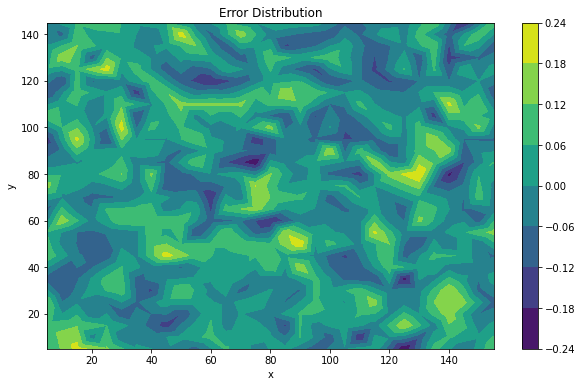

0.09280807

In [40]:
ENC.predict(stand="in", plot=False, test_dataloader=ENC.train_dataloader)

indx = 51      # ADAPT CLASS (model or data) TO AUTOENCODER STRUCTURES
xy = 0

plt_outputs = ENC.test_outputs[indx] #.reshape(X_recon.shape[1]//2, 2)[:,xy]
truth = ENC.truth[indx] #.reshape(X_recon.shape[1]//2,2)[:,xy]

plot_Distribution(ENC.data.train_in1, plt_outputs, truth=truth, typ="contour")

np.mean(np.sqrt(np.mean(np.square(ENC.test_outputs - ENC.truth), axis=1)))

In [52]:
def objective(trial):
    # lr = trial.suggest_float('lr', 1e-5, 1e-2, log=True)
    # batch_size = trial.suggest_categorical('batch_size', [1, 2, 4])
    latent_size = trial.suggest_int('latent_size', 50, 500, step=10)

    model_instance = MODEL(
        typ="MLP",
        model=Autoencoder(in_size, latent_size, h_size, block="mlp").to(device),
        lossf=nn.MSELoss(),
        opt=("adam", 0),
        batch=BATCH_SIZE,
        lr=LEARNING_RATE,
        data=DAT,
        train_dataloader=train_dataloader,
        val_dataloader=None,
        scheduler=("min", 0.7, 10, 1e-4, True),
        earlyStop=EarlyStopping(patience=10, verbose=False),
        w_init=weights_init,
        optTrial=trial  # Pass the trial object here
    )

    model_instance.train(n_epochs=1000, verbose=50)
    return model_instance.best_loss

study = hOpt(objective, n_trials=20, prnt=True, save=False, path="models/", name="Autoencoder-DimReduction")

[I 2025-06-20 10:56:42,072] A new study created in memory with name: no-name-e5f39627-7b7a-428f-8f2f-9abb44703ab9


Epoch: 1 - Loss: 1.7350435256958008
Epoch: 50 - Loss: 0.42047566175460815


[I 2025-06-20 10:57:15,331] Trial 0 finished with value: 0.37034550309181213 and parameters: {'latent_size': 470}. Best is trial 0 with value: 0.37034550309181213.


Best Epoch: 72, with loss 0.37034550309181213
Epoch: 1 - Loss: 1.9050889015197754
Epoch: 50 - Loss: 0.3338008522987366


[I 2025-06-20 10:57:34,178] Trial 1 finished with value: 0.3063221275806427 and parameters: {'latent_size': 370}. Best is trial 1 with value: 0.3063221275806427.


...

Epoch: 1 - Loss: 1.9267117977142334


[I 2025-06-20 10:58:48,231] Trial 17 pruned. 
[I 2025-06-20 10:58:48,518] Trial 18 pruned. 


Epoch: 1 - Loss: 1.9991337060928345


[I 2025-06-20 10:58:49,015] Trial 19 pruned. 



 Optimization Finished. Study statistics: 
  Number of finished trials: 20

Best trial 
 Loss: 0.2698553800582886

 Hyperparameters:
  latent_size: 330


In [16]:
load_bestParams(path="models/", name="Autoencoder-DimReduction")

{'latent_size': 280}